In [ ]:
from numpy import loadtxt
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Dense
from sklearn.model_selection import train_test_split
import pandas as pd
import tensorflow as tf
from sklearn.metrics import ConfusionMatrixDisplay
import matplotlib.pyplot as plt

In [ ]:
import pandas as pd

dataset = pd.read_csv('/content/dataset.csv', encoding='utf-8-sig')

dataset = pd.get_dummies(
    dataset,
    columns=['departamento', 'marca_moto'],
    drop_first=True
)

dataset = dataset.replace('', pd.NA)
dataset = dataset.apply(pd.to_numeric)
dataset = dataset.fillna(dataset.median())

# Asegurar que la variable objetivo quede al final
y = dataset['mora_antes_mes_6']
X = dataset.drop(columns=['mora_antes_mes_6'])

dataset_final = pd.concat([X, y], axis=1)

dataset_final.to_csv(
    '/content/dataset_modelo_sin_encabezado.csv',
    index=False,
    header=False
)

dataset_final.head()

,plazo,monto,score_inicial,ingreso_declarado,dias_promedio_entre_cuotas_pagadas,departamento_Escuintla,departamento_Guatemala,departamento_Guatemla,departamento_Jutiapa,departamento_Mixco,departamento_Quetzaltenango,departamento_Retalhuleu,departamento_San Marcos,departamento_Villa Nueva,departamento_Zacapa,marca_moto_Suzuki,marca_moto_Yamaha,mora_antes_mes_6
0,24,18000.0,720,6500.0,30.428571,False,True,False,False,False,False,False,False,False,False,False,False,0
1,36,22000.0,750,8000.0,30.833333,False,False,False,False,True,False,False,False,False,False,False,True,0
2,18,15000.0,680,5500.0,30.000000,False,False,False,False,False,False,False,False,True,False,False,False,0
3,36,28000.0,790,12000.0,30.833333,False,False,False,False,False,True,False,False,False,False,False,True,0
4,12,12000.0,640,4800.0,30.833333,True,False,False,False,False,False,False,False,False,False,False,False,0


In [ ]:
y = dataset['mora_antes_mes_6']
X = dataset.drop(columns=['mora_antes_mes_6'])
dataset_final = pd.concat([X, y], axis=1)
dataset_np = dataset_final.to_numpy(dtype='float32')

# Variables independientes y dependiente
X = dataset_np[:, 0:-1]
y = dataset_np[:, -1]

In [ ]:
y.shape

(84,)

In [ ]:
corte = int(len(X) * 0.70)

X_train, X_test = X[:corte, :], X[corte:, :]
y_train, y_test = y[:corte], y[corte:]

In [ ]:
print("Total registros:", len(X))
print("X_train:", X_train.shape)
print("X_test:", X_test.shape)
print("y_train:", y_train.shape)
print("y_test:", y_test.shape)

Total registros: 84
X_train: (58, 17)
X_test: (26, 17)
y_train: (58,)
y_test: (26,)


In [ ]:
X_train.shape

(58, 17)

In [ ]:
tf.keras.utils.set_random_seed(42)

In [ ]:
# Definición del modelo
model = Sequential()
# Agregando la primer capa
model.add(Dense(128, activation='relu'))
# Agregando la segunda capa
model.add(Dense(64, activation='relu'))
# Agregando la tercer capa
model.add(Dense(16, activation='relu'))
# Agregando la cuarta capa
model.add(Dense(32, activation='relu'))
# Agregando la última capa, la cual predice y_hat con la función sigmoid como activación
model.add(Dense(1, activation='sigmoid'))


In [ ]:
# Compilando el modelo, con la función de perdida "binary_crossentropy" por ser un problema de clasificación binario.
model.compile(loss='binary_crossentropy', optimizer='adam', metrics=['accuracy'])


In [ ]:
model.fit(X_train, y_train, epochs=125, batch_size=16, verbose=1)


Epoch 1/125
4/4 ━━━━━━━━━━━━━━━━━━━━ 2s 10ms/step - accuracy: 0.4655 - loss: 175.3173  
Epoch 2/125
4/4 ━━━━━━━━━━━━━━━━━━━━ 0s 9ms/step - accuracy: 0.9828 - loss: 11.7210    
Epoch 3/125
4/4 ━━━━━━━━━━━━━━━━━━━━ 0s 12ms/step - accuracy: 0.9828 - loss: 14.6392   
Epoch 4/125
4/4 ━━━━━━━━━━━━━━━━━━━━ 0s 11ms/step - accuracy: 0.9828 - loss: 15.7544   
Epoch 5/125
4/4 ━━━━━━━━━━━━━━━━━━━━ 0s 10ms/step - accuracy: 0.9828 - loss: 15.5545   
Epoch 6/125
4/4 ━━━━━━━━━━━━━━━━━━━━ 0s 10ms/step - accuracy: 0.9828 - loss: 14.9565   
Epoch 7/125
4/4 ━━━━━━━━━━━━━━━━━━━━ 0s 10ms/step - accuracy: 0.9828 - loss: 13.8862   
Epoch 8/125
4/4 ━━━━━━━━━━━━━━━━━━━━ 0s 10ms/step - accuracy: 0.9828 - loss: 12.7310   
Epoch 9/125
4/4 ━━━━━━━━━━━━━━━━━━━━ 0s 11ms/step - accuracy: 0.9828 - loss: 11.4633   
Epoch 10/125
4/4 ━━━━━━━━━━━━━━━━━━━━ 0s 10ms/step - accuracy: 0.9828 - loss: 10.1016   
Epoch 11/125
4/4 ━━━━━━━━━━━━━━━━━━━━ 0s 11ms/step - accuracy: 0.9828 - loss: 8.6584    
Epoch 12/125
4/4 ━━━━━━━━━━━━━

In [ ]:
# Evaluando el rendimiento del modelo
loss, accuracy = model.evaluate(X_train, y_train)
print('Precisión: %.2f' %(accuracy*100))

2/2 ━━━━━━━━━━━━━━━━━━━━ 0s 22ms/step - accuracy: 0.9828 - loss: 2.0944 
Precisión: 98.28


In [ ]:
loss, accuracy = model.evaluate(X_test, y_test)
print('Precisión: %.2f' %(accuracy*100))

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 42ms/step - accuracy: 0.8462 - loss: 37.1854
Precisión: 84.62


AUC EN DATA SET DE PRUEBA ES DE 84.62%

In [ ]:
from sklearn.metrics import confusion_matrix, ConfusionMatrixDisplay
import matplotlib.pyplot as plt

# Predicción en probabilidades
y_prob = model.predict(X_test)

# Convertir probabilidades a 0 y 1
y_pred = (y_prob >= 0.5).astype(int).ravel()

# Asegurar que y_test también esté en formato entero
y_test_int = y_test.astype(int)

# Matriz de confusión
matriz = confusion_matrix(y_test_int, y_pred, labels=[0, 1])

print("Matriz de confusión:")
print(matriz)

# Extraer valores
vn, fp, fn, vp = matriz.ravel()

print("Verdaderos negativos:", vn)
print("Falsos positivos:", fp)
print("Falsos negativos:", fn)
print("Verdaderos positivos:", vp)

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 180ms/step
Matriz de confusión:
[[22  0]
 [ 4  0]]
Verdaderos negativos: 22
Falsos positivos: 0
Falsos negativos: 4
Verdaderos positivos: 0


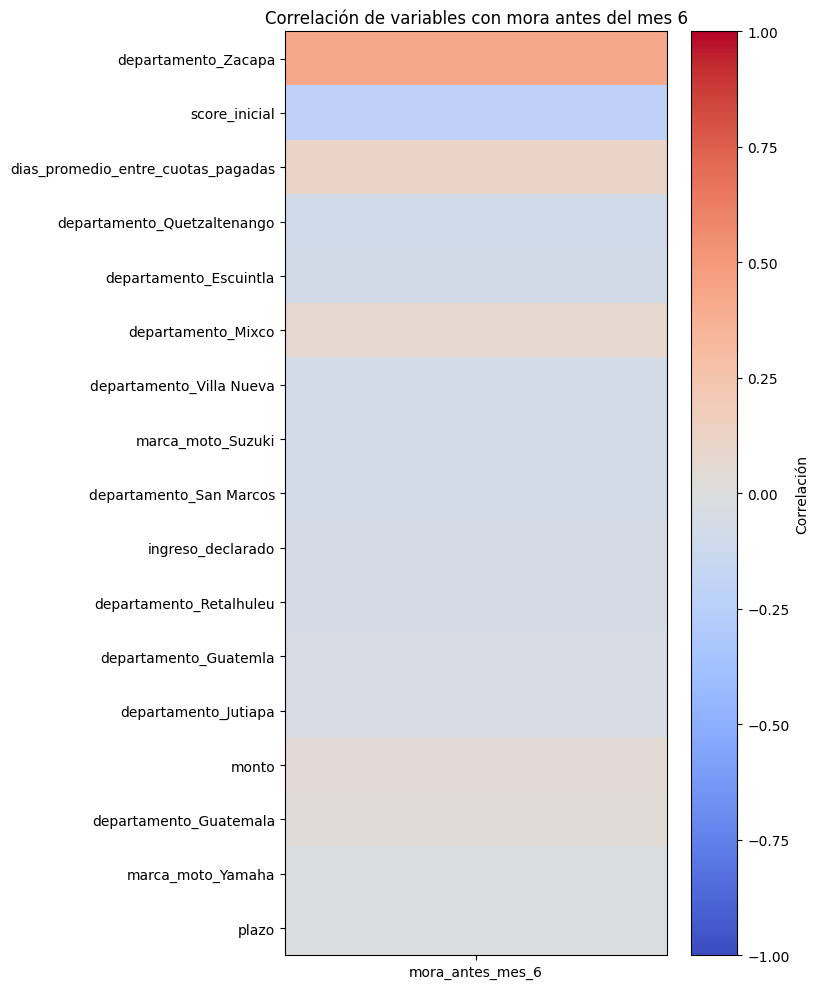

In [ ]:
# Matriz de correlación
correlacion = dataset_final.corr()

# Correlación de cada variable contra la variable objetivo
corr_mora = correlacion[['mora_antes_mes_6']].drop('mora_antes_mes_6')

# Ordenar de mayor a menor según correlación absoluta
corr_mora = corr_mora.reindex(
    corr_mora['mora_antes_mes_6'].abs().sort_values(ascending=False).index
)

# Gráfico tipo heatmap
plt.figure(figsize=(8, 10))

plt.imshow(
    corr_mora,
    cmap='coolwarm',
    aspect='auto',
    vmin=-1,
    vmax=1
)

plt.colorbar(label='Correlación')
plt.xticks([0], ['mora_antes_mes_6'])
plt.yticks(range(len(corr_mora.index)), corr_mora.index)

plt.title('Correlación de variables con mora antes del mes 6')
plt.tight_layout()
plt.show()

In [ ]:
top3 = corr_mora.copy()
top3['correlacion_absoluta'] = top3['mora_antes_mes_6'].abs()

top3 = top3.sort_values(
    by='correlacion_absoluta',
    ascending=False
).head(3)
print("variables mas importantes")
print(top3)

variables mas importantes
                                    mora_antes_mes_6  correlacion_absoluta
departamento_Zacapa                         0.416283              0.416283
score_inicial                              -0.215855              0.215855
dias_promedio_entre_cuotas_pagadas          0.116018              0.116018


el modelo tiene limitaciones por la cantidad de informacion que le estamos ingresando, no tiene suficiente historia para aprender, tener cuidado al tomar decisiones con dicho modelo.